# Machine Learning Models — Olist E-Commerce Big Data Project

Notebook này trình bày **toàn bộ quy trình** xây dựng 3 mô hình Machine Learning cho dự án Big Data trên bộ dữ liệu Olist, dùng **Spark MLlib**

**3 mô hình sẽ xây dựng:**
1. **K-Means Customer Segmentation** — phân cụm khách hàng theo RFM (Recency, Frequency, Monetary)
2. **Churn Prediction** — dự đoán khách hàng rời bỏ (GBTClassifier)
3. **Review Score Prediction** — dự đoán điểm đánh giá đơn hàng (RandomForestRegressor / LinearRegression)

**Quy trình chung**

1. **Xác định bài toán & mục tiêu kinh doanh** — model giải quyết câu hỏi gì?
2. **Kiểm tra & khám phá dữ liệu (EDA)** — schema, số dòng, null, phân bố, kiểu dữ liệu
3. **Chọn & xử lý features** — cột nào dùng được, cần fill null/scale/encode không?
4. **Xây pipeline tiền xử lý** — VectorAssembler, StandardScaler, StringIndexer...
5. **Chọn thuật toán phù hợp với bài toán** (phân cụm / phân loại / hồi quy)
6. **Train / Test split** — tránh đánh giá model trên chính dữ liệu đã học
7. **Huấn luyện model**
8. **Đánh giá bằng metric phù hợp** (Silhouette / AUC-F1 / RMSE-R2)
9. **Diễn giải kết quả** (feature importance, confusion matrix, cluster centers)
10. **Lưu model + kết quả** để dùng lại (API, dashboard, báo cáo)

## 1. Cài đặt môi trường & khởi tạo Spark

In [34]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import sys
import json
import logging
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Buoc PySpark dung Python 3.12 (Python 3.13 khong tuong thich)
PYTHON_PATH = "C:/Users/Admin/AppData/Local/Programs/Python/Python312/python.exe"
os.environ["PYSPARK_PYTHON"] = PYTHON_PATH
os.environ["PYSPARK_DRIVER_PYTHON"] = PYTHON_PATH

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, StringIndexer
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import (
    RandomForestClassifier, LogisticRegression, GBTClassifier
)
from pyspark.ml.regression import (
    RandomForestRegressor,
    LinearRegression as SparkLinearRegression
)
from pyspark.ml.evaluation import (
    ClusteringEvaluator,
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    RegressionEvaluator
)
from pyspark.ml.functions import vector_to_array

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("OlistML")

HDFS_SILVER = "hdfs://localhost:9000/user/bigdata/olist/silver"
HDFS_GOLD = "hdfs://localhost:9000/user/bigdata/olist/gold"
HDFS_MODELS = "hdfs://localhost:9000/user/bigdata/olist/models"

In [36]:
spark = (
    SparkSession.builder
    .appName("Olist_ML_Models")
    .master("local[2]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.ui.enabled", "false")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.pyspark.python", PYTHON_PATH)
    .config("spark.pyspark.driver.python", PYTHON_PATH)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("SparkSession da khoi tao thanh cong.")

SparkSession da khoi tao thanh cong.


## 2. Đọc dữ liệu & Kiểm tra chất lượng dữ liệu (EDA)
Dữ liệu đầu vào ở đây là output đã qua ETL (tầng Silver/Gold), đọc từ HDFS dưới dạng Parquet:
- `merged_orders`: bảng đơn hàng đã join đầy đủ (giá, phí ship, review, thời gian giao hàng...)
- `rfm_customers`: bảng RFM (Recency, Frequency, Monetary) đã tính sẵn theo khách hàng

In [38]:
merged_df = spark.read.parquet(f"{HDFS_SILVER}/merged_orders")
rfm_df = spark.read.parquet(f"{HDFS_GOLD}/rfm_customers")

merged_count = merged_df.count()
rfm_count = rfm_df.count()
print(f"merged_orders: {merged_count:,} dong")
print(f"rfm_customers: {rfm_count:,} dong")

merged_orders: 99,277 dong
rfm_customers: 93,358 dong


**Kiểm tra schema**

In [39]:
merged_df.printSchema()
rfm_df.printSchema()

root
 |-- customer_unique_id: string (nullable = true)
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)
 |-- customer_zip_code_prefix: integer (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- total_items: long (nullable = true)
 |-- total_price: double (nullable = true)
 |-- total_freight_value: double (nullable = true)
 |-- unique_products: long (nullable = true)
 |-- unique_sellers: long (nullable = true)
 |-- main_category_english: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- seller_city: string (nullable = true)
 |-

**Kiểm tra thống kê mô tả (describe)** - phát hiện outlier, giá trị âm bất thường, min/max vô lý:

In [40]:
rfm_df.select("recency", "frequency", "monetary").describe().show()

+-------+------------------+-------------------+------------------+
|summary|           recency|          frequency|          monetary|
+-------+------------------+-------------------+------------------+
|  count|             93358|              93358|             93358|
|   mean|237.47887701107564| 1.0334197390689603|165.19700261358162|
| stddev| 152.5950542957237|0.20909743968188677|226.31401249105576|
|    min|                 0|                  1|               0.0|
|    max|               713|                 15|          13664.08|
+-------+------------------+-------------------+------------------+



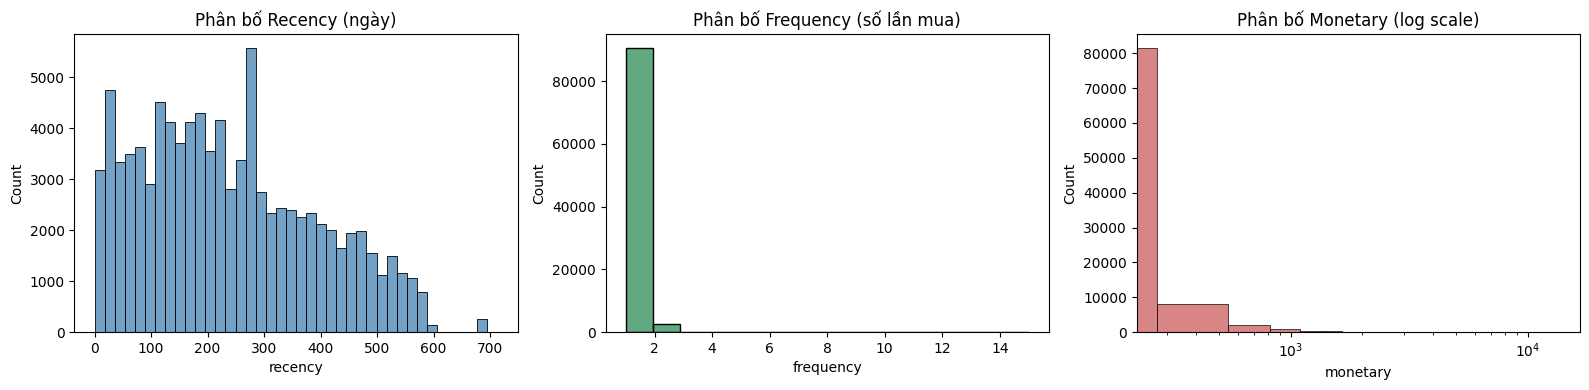

In [41]:
rfm_pd = rfm_df.select("recency", "frequency", "monetary").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm_pd["recency"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Phân bố Recency (ngày)")

sns.histplot(rfm_pd["frequency"], bins=15, ax=axes[1], color="seagreen")
axes[1].set_title("Phân bố Frequency (số lần mua)")

# Monetary thường lệch phải mạnh -> dùng log scale để nhìn rõ hơn
sns.histplot(rfm_pd["monetary"], bins=50, ax=axes[2], color="indianred")
axes[2].set_xscale("log")
axes[2].set_title("Phân bố Monetary (log scale)")

plt.tight_layout()
plt.show()

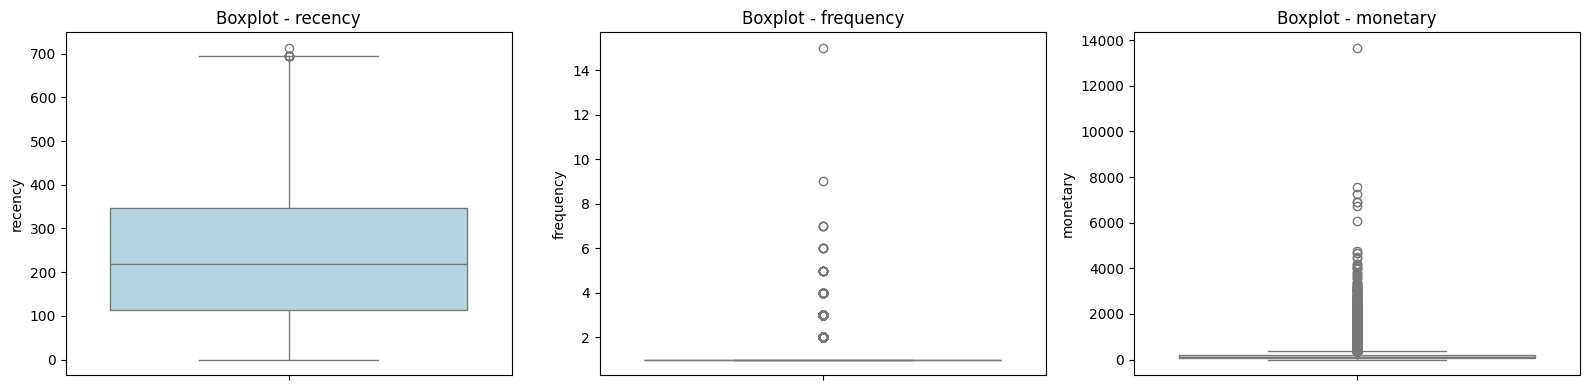

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["recency", "frequency", "monetary"]):
    sns.boxplot(y=rfm_pd[col], ax=ax, color="lightblue")
    ax.set_title(f"Boxplot - {col}")
plt.tight_layout()
plt.show()

**Kiểm tra tỉ lệ null trên các cột sẽ dùng làm feature**

In [45]:
from pyspark.sql.functions import col, sum as spark_sum, when

check_cols = ["recency", "frequency", "monetary"]
rfm_df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in check_cols
]).show()

+-------+---------+--------+
|recency|frequency|monetary|
+-------+---------+--------+
|      0|        0|       0|
+-------+---------+--------+



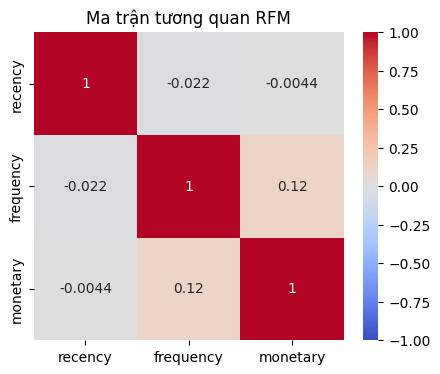

In [43]:
corr = rfm_pd.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Ma trận tương quan RFM")
plt.show()

## 3. Mô hình 1: K-Means Customer Segmentation

Bài toán "phân khúc khách hàng" là bài toán **không giám sát (unsupervised)** - không có nhãn đúng/sai để học theo, mà ta sẽ nhóm khách hàng có hành vi tương tự lại với nhau. K-Means là thuật toán phân cụm phổ biến nhất cho dữ liệu numeric, dựa trên khoảng cách Euclidean.

Đây là bộ 3 chỉ số kinh điển trong phân tích khách hàng (Customer Analytics):
- **Recency**: bao lâu rồi khách chưa mua (càng nhỏ càng tốt)
- **Frequency**: mua bao nhiêu lần (càng lớn càng tốt)
- **Monetary**: tổng chi tiêu (càng lớn càng tốt)

K-Means dựa vào khoảng cách. Nếu `monetary` có giá trị hàng nghìn còn `recency` chỉ vài trăm, cột có giá trị lớn hơn sẽ **áp đảo** khoảng cách một cách giả tạo. Do đó bắt buộc phải chuẩn hóa (StandardScaler) trước khi tính khoảng cách.

**3.1 - Chuẩn bị & làm sạch dữ liệu feature:**

In [7]:
feature_cols = ["recency", "frequency", "monetary"]
clean_df = (
    rfm_df
    .select("customer_unique_id", *feature_cols)
    .na.drop(subset=feature_cols)
)
data_count = clean_df.count()
print(f"Du lieu K-Means: {data_count:,} khach hang")

Du lieu K-Means: 93,358 khach hang


**3.2 — Xây pipeline: VectorAssembler -> StandardScaler -> KMeans**

- `VectorAssembler`: gộp nhiều cột số thành 1 vector `features`
- `StandardScaler`: chuẩn hóa về mean=0, std=1
- `KMeans(k=4)`: chọn k=4 vì muốn phân thành 4 nhóm dễ diễn giải kinh doanh (Champions/Loyal/At Risk/Lost). Trong thực tế, số k tối ưu có thể xác định bằng Elbow Method hoặc Silhouette Score.

In [8]:
assembler = VectorAssembler(
    inputCols=feature_cols, outputCol="features_raw"
)
scaler = StandardScaler(
    inputCol="features_raw", outputCol="features",
    withStd=True, withMean=True
)
kmeans = KMeans(
    featuresCol="features", predictionCol="cluster",
    k=4, seed=42, maxIter=30
)
pipeline = Pipeline(stages=[assembler, scaler, kmeans])

print("Dang huan luyen K-Means (k=4)...")
kmeans_model_full = pipeline.fit(clean_df)
predictions = kmeans_model_full.transform(clean_df)

Dang huan luyen K-Means (k=4)...


**3.3 - Đánh giá bằng Silhouette Score**

**Silhouette Score** (khoảng -1 đến 1) đo mức độ 1 điểm dữ liệu "gần" với cụm của nó so với các cụm khác - càng gần 1 càng tốt (cụm tách biệt rõ ràng).

In [9]:
evaluator = ClusteringEvaluator(
    featuresCol="features", predictionCol="cluster",
    metricName="silhouette"
)
silhouette = evaluator.evaluate(predictions)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.3054


**3.4 - Diễn giải cụm: đặt tên phân khúc dựa vào cluster centers**

Model chỉ trả về số cluster (0,1,2,3) — không có ý nghĩa kinh doanh. Ta phải tự diễn giải: cụm nào có `monetary` trung bình cao nhất -> khách hàng giá trị nhất ("Champions"), thấp nhất -> có nguy cơ rời bỏ nhất ("Lost").

In [10]:
kmeans_model = kmeans_model_full.stages[-1]
centers = kmeans_model.clusterCenters()

# Sap xep cac cluster theo monetary (index 2 trong vector) giam dan
indexed_centers = [
    (i, float(centers[i][2]))
    for i in range(len(centers))
]
indexed_centers.sort(key=lambda x: x[1], reverse=True)

segment_names = ["Champions", "Loyal", "At Risk", "Lost"]
cluster_to_segment = {}
for rank, (cluster_id, monetary_val) in enumerate(indexed_centers):
    cluster_to_segment[cluster_id] = segment_names[rank]
    print(f"Cluster {cluster_id} -> {segment_names[rank]}")

Cluster 2 -> Champions
Cluster 1 -> Loyal
Cluster 3 -> At Risk
Cluster 0 -> Lost


In [11]:
condition = None
for cid, name in cluster_to_segment.items():
    if condition is None:
        condition = F.when(F.col("cluster") == cid, F.lit(name))
    else:
        condition = condition.when(F.col("cluster") == cid, F.lit(name))
condition = condition.otherwise(F.lit("Unknown"))

segmented_df = predictions.withColumn("segment_name", condition)

print("Phan bo phan khuc khach hang:")
segment_stats = {}
for cid, name in cluster_to_segment.items():
    count = segmented_df.filter(F.col("cluster") == cid).count()
    segment_stats[name] = int(count)
    print(f"  {name}: {count:,} khach hang")

Phan bo phan khuc khach hang:
  Champions: 2,807 khach hang
  Loyal: 33,796 khach hang
  At Risk: 22,276 khach hang
  Lost: 34,479 khach hang


**3.5 - Lưu model và kết quả lên HDFS**:

In [12]:
model_path = f"{HDFS_MODELS}/kmeans_segmentation"
kmeans_model_full.write().overwrite().save(model_path)

output_path = f"{HDFS_GOLD}/customer_segments"
(
    segmented_df
    .select(
        "customer_unique_id", "recency", "frequency", "monetary",
        "cluster", "segment_name"
    )
    .coalesce(2)
    .write.mode("overwrite")
    .parquet(output_path)
)

kmeans_results = {
    "model_name": "KMeans_Segmentation",
    "k": 4,
    "silhouette_score": round(silhouette, 4),
    "cluster_mapping": {str(k): v for k, v in cluster_to_segment.items()},
    "segment_stats": segment_stats,
}
kmeans_results

{'model_name': 'KMeans_Segmentation',
 'k': 4,
 'silhouette_score': 0.3054,
 'cluster_mapping': {'2': 'Champions',
  '1': 'Loyal',
  '3': 'At Risk',
  '0': 'Lost'},
 'segment_stats': {'Champions': 2807,
  'Loyal': 33796,
  'At Risk': 22276,
  'Lost': 34479}}

## 4. Mô hình 2: Churn Prediction (Classification)

### Bài toán
Dự đoán khách hàng nào có khả năng **rời bỏ (churn)** - đây là bài toán **phân loại nhị phân có giám sát**: cần một nhãn (label) đúng/sai để model học.

### Vấn đề: dữ liệu Olist không có nhãn churn sẵn - phải tự định nghĩa
Vì đây là dữ liệu e-commerce lịch sử (không có cột "đã rời bỏ hay chưa"), ta phải **tự xây dựng nhãn (label) dựa trên logic nghiệp vụ*.

Cách đơn giản nhất là coi khách hàng "churn" nếu lâu ngày không mua (recency lớn). Nhưng cách này bỏ qua nhiều tín hiệu khác. Nên ở đây dùng **điểm rủi ro tổng hợp (composite risk score)** kết hợp 5 yếu tố có trọng số:

| Yếu tố | Trọng số | Ý nghĩa |
|---|---|---|
| Recency | 30% | Lâu không mua = xấu |
| Frequency | 15% (nghịch đảo) | Mua ít lần = xấu |
| Monetary | 15% (nghịch đảo) | Chi tiêu ít = xấu |
| Avg review score | 20% (nghịch đảo) | Đánh giá thấp = xấu |
| Avg delivery days | 20% | Giao hàng chậm = xấu |

Khách hàng có `risk_score > 0.5` được gán nhãn `churn = 1`. Việc chọn ngưỡng 0.5 và trọng số này mang tính giả định nghiệp vụ, có thể điều chỉnh sau khi phân tích thêm.

### Vì sao chọn GBTClassifier (Gradient Boosted Trees)?
So với Logistic Regression hay Random Forest đơn giản, GBT thường cho độ chính xác cao hơn trên dữ liệu tabular vì học tuần tự để sửa lỗi của cây trước đó, tốt cho quan hệ phi tuyến giữa các feature.

**4.1 - Tính thêm feature ở mức khách hàng và join với RFM:**

In [13]:
customer_features = (
    merged_df
    .groupBy("customer_unique_id")
    .agg(
        F.avg("avg_review_score").alias("avg_review"),
        F.avg("delivery_days").alias("avg_delivery_days"),
    )
)

ml_df = (
    rfm_df
    .select("customer_unique_id", "recency", "frequency", "monetary")
    .join(customer_features, on="customer_unique_id", how="inner")
)

fill_values = {
    "recency": 0.0, "frequency": 1.0, "monetary": 0.0,
    "avg_review": 4.0, "avg_delivery_days": 10.0
}
ml_df = ml_df.fillna(fill_values)
ml_df.show(5)

+--------------------+-------+---------+--------+----------+-----------------+
|  customer_unique_id|recency|frequency|monetary|avg_review|avg_delivery_days|
+--------------------+-------+---------+--------+----------+-----------------+
|0004aac84e0df4da2...|    288|        1|  196.89|       5.0|             13.0|
|000c8bdb58a29e711...|    260|        1|    29.0|       5.0|             15.0|
|000ec5bff359e1c0a...|      8|        1|   27.75|       5.0|              6.0|
|001a2bf0e46c68403...|    426|        1|   36.73|       4.0|              4.0|
|0027324a96d26a2bc...|    157|        1|   46.78|       5.0|              3.0|
+--------------------+-------+---------+--------+----------+-----------------+
only showing top 5 rows



**4.2 - Tính Composite Risk Score và gán nhãn `label`:**

Mỗi thành phần được chuẩn hóa về [0, 1] (`_n` = normalized) trước khi cộng có trọng số, để các đơn vị khác nhau (ngày, số lần, tiền, điểm review) có thể so sánh công bằng với nhau.

In [14]:
ml_df = ml_df.withColumn("rec_n", F.least(F.col("recency") / 730.0, F.lit(1.0)))
ml_df = ml_df.withColumn("freq_n", F.least((F.col("frequency") - 1) / 19.0, F.lit(1.0)))
ml_df = ml_df.withColumn("mon_n", F.least(F.col("monetary") / 5000.0, F.lit(1.0)))
ml_df = ml_df.withColumn("rev_n", (F.col("avg_review") - 1) / 4.0)
ml_df = ml_df.withColumn("del_n", F.least(F.col("avg_delivery_days") / 60.0, F.lit(1.0)))

ml_df = ml_df.withColumn(
    "risk",
    0.30 * F.col("rec_n") +
    0.15 * (1.0 - F.col("freq_n")) +
    0.15 * (1.0 - F.col("mon_n")) +
    0.20 * (1.0 - F.col("rev_n")) +
    0.20 * F.col("del_n")
)
ml_df = ml_df.withColumn("label", F.when(F.col("risk") > 0.50, 1.0).otherwise(0.0))

feature_cols = ["recency", "frequency", "monetary", "avg_review", "avg_delivery_days"]

data_count = ml_df.count()
churn_1 = ml_df.filter(F.col("label") == 1.0).count()
churn_0 = ml_df.filter(F.col("label") == 0.0).count()
print(f"Du lieu: {data_count:,} khach hang")
print(f"Churn=1 (roi bo): {churn_1:,}, Churn=0 (giu lai): {churn_0:,}")

Du lieu: 93,358 khach hang
Churn=1 (roi bo): 34,515, Churn=0 (giu lai): 58,843


**4.3 - Xử lý mất cân bằng dữ liệu (Class Imbalance) bằng Class Weights**

Nếu số lượng churn=1 và churn=0 chênh lệch nhiều, model sẽ có xu hướng thiên vị đoán về lớp đa số. Thay vì oversampling/undersampling (tốn thêm dữ liệu giả), ở đây dùng **class weights**: gán trọng số cao hơn cho lớp thiểu số khi tính loss, để model "chú ý" nhiều hơn đến các trường hợp churn hiếm gặp.

In [15]:
w_1 = data_count / (2 * churn_1) if churn_1 > 0 else 1.0
w_0 = data_count / (2 * churn_0) if churn_0 > 0 else 1.0
ml_df = ml_df.withColumn("weight", F.when(F.col("label") == 1.0, w_1).otherwise(w_0))
print(f"weight class 1: {w_1:.3f}, weight class 0: {w_0:.3f}")

weight class 1: 1.352, weight class 0: 0.793


**4.4 - Train/Test split**

Luôn tách dữ liệu train/test trước khi đánh giá - nếu đánh giá trên chính dữ liệu đã train, kết quả sẽ ảo (overfitting không bị phát hiện). `seed=42` để đảm bảo kết quả tái lập được (reproducible).

In [16]:
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,}, Test: {test_df.count():,}")

Train: 74,775, Test: 18,583


**4.5 - Xây pipeline & huấn luyện GBTClassifier:**

In [17]:
assembler = VectorAssembler(
    inputCols=feature_cols, outputCol="features",
    handleInvalid="skip"
)

gbt = GBTClassifier(
    featuresCol="features", labelCol="label", weightCol="weight",
    maxIter=50, maxDepth=5, seed=42
)
gbt_pipeline = Pipeline(stages=[assembler, gbt])

print("Dang huan luyen GBTClassifier...")
best_model = gbt_pipeline.fit(train_df)
best_preds = best_model.transform(test_df)
best_name = "GradientBoosting"

Dang huan luyen GBTClassifier...


**Bước 4.6 - Đánh giá model bằng nhiều metric**

In [18]:
auc_eval = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
acc_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
prec_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
rec_eval = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")

gbt_metrics = {
    "auc_roc": round(auc_eval.evaluate(best_preds), 4),
    "accuracy": round(acc_eval.evaluate(best_preds), 4),
    "f1_score": round(f1_eval.evaluate(best_preds), 4),
    "precision": round(prec_eval.evaluate(best_preds), 4),
    "recall": round(rec_eval.evaluate(best_preds), 4),
}
gbt_metrics

{'auc_roc': 0.9992,
 'accuracy': 0.9853,
 'f1_score': 0.9853,
 'precision': 0.9855,
 'recall': 0.9853}

**4.7 - Confusion Matrix**

In [19]:
tp = best_preds.filter((F.col("label") == 1.0) & (F.col("prediction") == 1.0)).count()
tn = best_preds.filter((F.col("label") == 0.0) & (F.col("prediction") == 0.0)).count()
fp = best_preds.filter((F.col("label") == 0.0) & (F.col("prediction") == 1.0)).count()
fn = best_preds.filter((F.col("label") == 1.0) & (F.col("prediction") == 0.0)).count()
print(f"Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")

Confusion Matrix: TP=6796, TN=11514, FP=214, FN=59


**4.8 - Feature Importance**

Cho biết feature nào ảnh hưởng nhiều nhất đến quyết định của model

In [20]:
gbt_classifier = best_model.stages[-1]
importances = gbt_classifier.featureImportances.toArray().tolist()
fi_dict = {}
for i, name in enumerate(feature_cols):
    fi_dict[name] = round(importances[i], 4) if i < len(importances) else 0.0
fi_sorted = dict(sorted(fi_dict.items(), key=lambda x: x[1], reverse=True))

for feat, imp in fi_sorted.items():
    print(f"  {feat}: {imp:.4f}")

  recency: 0.4603
  avg_review: 0.3829
  avg_delivery_days: 0.1414
  monetary: 0.0148
  frequency: 0.0007


**4.9 - Lưu model & kết quả dự đoán:**

In [21]:
model_path = f"{HDFS_MODELS}/churn_classifier"
best_model.write().overwrite().save(model_path)

churn_output = (
    best_preds
    .withColumn("prob_array", vector_to_array("probability"))
    .withColumn("churn_probability", F.round(F.element_at("prob_array", 2), 4))
    .select("customer_unique_id", "label", "prediction", "churn_probability")
)
output_path = f"{HDFS_GOLD}/churn_predictions"
churn_output.coalesce(2).write.mode("overwrite").parquet(output_path)

churn_results = {
    "model_name": "Churn_Prediction",
    "best_model": best_name,
    "models": {"GradientBoosting": gbt_metrics},
    "confusion_matrix": {
        "true_positive": int(tp), "true_negative": int(tn),
        "false_positive": int(fp), "false_negative": int(fn)
    },
    "feature_importance": fi_sorted,
    "features_used": feature_cols
}
churn_results

{'model_name': 'Churn_Prediction',
 'best_model': 'GradientBoosting',
 'models': {'GradientBoosting': {'auc_roc': 0.9992,
   'accuracy': 0.9853,
   'f1_score': 0.9853,
   'precision': 0.9855,
   'recall': 0.9853}},
 'confusion_matrix': {'true_positive': 6796,
  'true_negative': 11514,
  'false_positive': 214,
  'false_negative': 59},
 'feature_importance': {'recency': 0.4603,
  'avg_review': 0.3829,
  'avg_delivery_days': 0.1414,
  'monetary': 0.0148,
  'frequency': 0.0007},
 'features_used': ['recency',
  'frequency',
  'monetary',
  'avg_review',
  'avg_delivery_days']}

## 5. Mô hình 3: Review Score Prediction (Regression)

### Bài toán
Dự đoán **điểm đánh giá trung bình** (`avg_review_score`, giá trị liên tục 1-5) của một đơn hàng dựa trên các đặc điểm của đơn hàng đó. Vì label là **số liên tục** (không phải nhãn phân loại), đây là bài toán **hồi quy (regression)**

### Vì sao chọn features này?
- **Numeric**: `total_price`, `total_freight_value`, `delivery_days`, `total_payment_value`, `total_items`, `freight_ratio` - đây là các yếu tố có khả năng ảnh hưởng trực tiếp đến trải nghiệm khách hàng (giao hàng chậm, phí ship cao thường liên quan đến đánh giá thấp)
- **Categorical**: `main_category_english` (loại sản phẩm) — vì mức độ hài lòng có thể khác nhau giữa các ngành hàng

### Vì sao cần StringIndexer cho biến categorical?
MLlib không nhận string trực tiếp làm input — `StringIndexer` chuyển categorical (`main_category_english`) thành số nguyên (index) trước khi đưa vào `VectorAssembler`.

### Vì sao thử cả Random Forest lẫn Linear Regression?
Đây là thực hành tốt: **so sánh nhiều thuật toán** thay vì chỉ tin vào một model duy nhất.
- Linear Regression: baseline đơn giản, giả định quan hệ tuyến tính
- Random Forest Regressor: học được quan hệ phi tuyến phức tạp hơn, thường mạnh hơn nhưng khó diễn giải hơn

Model tốt hơn được chọn dựa trên **RMSE** (càng thấp càng tốt) trên tập test.

**5.1 - Chọn & làm sạch dữ liệu feature:**

In [22]:
numeric_features = [
    "total_price", "total_freight_value", "delivery_days",
    "total_payment_value", "total_items", "freight_ratio",
]
cat_feature = "main_category_english"
label_col = "avg_review_score"

review_df = (
    merged_df
    .select(*numeric_features, cat_feature, label_col)
    .na.drop(subset=[label_col])
)

fill_values = {col: 0.0 for col in numeric_features}
fill_values[cat_feature] = "unknown"
review_df = review_df.fillna(fill_values)

review_df = review_df.withColumn(
    "label", F.col(label_col).cast("double")
).filter(F.col("label").isNotNull())

data_count = review_df.count()
print(f"Du lieu: {data_count:,} dong")
print(f"Numeric features: {numeric_features}")
print(f"Categorical: {cat_feature}")

Du lieu: 96,631 dong
Numeric features: ['total_price', 'total_freight_value', 'delivery_days', 'total_payment_value', 'total_items', 'freight_ratio']
Categorical: main_category_english


**5.2 - Pipeline tiền xử lý: StringIndexer → VectorAssembler**

In [23]:
indexer = StringIndexer(
    inputCol=cat_feature, outputCol="category_index",
    handleInvalid="keep"
)
all_feature_cols = numeric_features + ["category_index"]

assembler = VectorAssembler(
    inputCols=all_feature_cols, outputCol="features",
    handleInvalid="skip"
)

train_df, test_df = review_df.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train_df.count():,}, Test: {test_df.count():,}")

Train: 77,272, Test: 19,359


**5.3 - Huấn luyện Random Forest Regressor:**

In [24]:
rf = RandomForestRegressor(
    featuresCol="features", labelCol="label",
    numTrees=50, maxDepth=8, maxBins=80, seed=42
)
rf_pipeline = Pipeline(stages=[indexer, assembler, rf])

print("Dang huan luyen Random Forest Regressor...")
rf_model = rf_pipeline.fit(train_df)
rf_preds = rf_model.transform(test_df)

Dang huan luyen Random Forest Regressor...


**5.4 - Huấn luyện Linear Regression:**

In [25]:
lr = SparkLinearRegression(
    featuresCol="features", labelCol="label",
    maxIter=100, regParam=0.01
)
lr_pipeline = Pipeline(stages=[indexer, assembler, lr])

print("Dang huan luyen Linear Regression...")
lr_model = lr_pipeline.fit(train_df)
lr_preds = lr_model.transform(test_df)

Dang huan luyen Linear Regression...


**5.5 - Đánh giá RMSE, R², MAE và chọn model tốt nhất:**

- **RMSE** (Root Mean Squared Error): sai số trung bình, phạt nặng các sai số lớn — càng thấp càng tốt
- **R²**: tỉ lệ phương sai được giải thích bởi model (0-1, càng gần 1 càng tốt)
- **MAE** (Mean Absolute Error): sai số tuyệt đối trung bình, dễ diễn giải hơn RMSE

In [26]:
rmse_eval = RegressionEvaluator(labelCol="label", metricName="rmse")
r2_eval = RegressionEvaluator(labelCol="label", metricName="r2")
mae_eval = RegressionEvaluator(labelCol="label", metricName="mae")

rf_metrics = {
    "rmse": round(rmse_eval.evaluate(rf_preds), 4),
    "r2": round(r2_eval.evaluate(rf_preds), 4),
    "mae": round(mae_eval.evaluate(rf_preds), 4),
}
print(f"RF  -> RMSE: {rf_metrics['rmse']}, R2: {rf_metrics['r2']}, MAE: {rf_metrics['mae']}")

lr_metrics = {
    "rmse": round(rmse_eval.evaluate(lr_preds), 4),
    "r2": round(r2_eval.evaluate(lr_preds), 4),
    "mae": round(mae_eval.evaluate(lr_preds), 4),
}
print(f"LR  -> RMSE: {lr_metrics['rmse']}, R2: {lr_metrics['r2']}, MAE: {lr_metrics['mae']}")

if rf_metrics["rmse"] <= lr_metrics["rmse"]:
    best_name = "RandomForest"
    best_model = rf_model
else:
    best_name = "LinearRegression"
    best_model = lr_model
print(f"-> Best model: {best_name}")

RF  -> RMSE: 1.1962, R2: 0.1669, MAE: 0.9229
LR  -> RMSE: 1.2216, R2: 0.1312, MAE: 0.9446
-> Best model: RandomForest


**5.6 - Feature Importance (từ Random Forest):**

In [27]:
rf_regressor = rf_model.stages[-1]
importances = rf_regressor.featureImportances.toArray().tolist()
fi_dict = {}
for i, name in enumerate(all_feature_cols):
    fi_dict[name] = round(importances[i], 4) if i < len(importances) else 0.0
fi_sorted = dict(sorted(fi_dict.items(), key=lambda x: x[1], reverse=True))

for feat, imp in fi_sorted.items():
    print(f"  {feat}: {imp:.4f}")

  delivery_days: 0.6930
  category_index: 0.1099
  total_items: 0.0871
  total_freight_value: 0.0544
  freight_ratio: 0.0202
  total_price: 0.0186
  total_payment_value: 0.0167


**5.7 - Lưu model tốt nhất:**

In [28]:
model_path = f"{HDFS_MODELS}/review_predictor"
best_model.write().overwrite().save(model_path)

review_results = {
    "model_name": "Review_Score_Prediction",
    "best_model": best_name,
    "models": {"RandomForest": rf_metrics, "LinearRegression": lr_metrics},
    "feature_importance": fi_sorted,
    "features_used": all_feature_cols,
}
review_results

{'model_name': 'Review_Score_Prediction',
 'best_model': 'RandomForest',
 'models': {'RandomForest': {'rmse': 1.1962, 'r2': 0.1669, 'mae': 0.9229},
  'LinearRegression': {'rmse': 1.2216, 'r2': 0.1312, 'mae': 0.9446}},
 'feature_importance': {'delivery_days': 0.693,
  'category_index': 0.1099,
  'total_items': 0.0871,
  'total_freight_value': 0.0544,
  'freight_ratio': 0.0202,
  'total_price': 0.0186,
  'total_payment_value': 0.0167},
 'features_used': ['total_price',
  'total_freight_value',
  'delivery_days',
  'total_payment_value',
  'total_items',
  'freight_ratio',
  'category_index']}

## 6. Tổng hợp kết quả & lưu ra JSON

In [29]:
elapsed_placeholder = 0  # thay bang thoi gian thuc te neu chay full pipeline
all_results = {
    "kmeans_segmentation": kmeans_results,
    "churn_prediction": churn_results,
    "review_prediction": review_results,
    "timestamp": datetime.now().isoformat(),
}

os.makedirs("tmp_models", exist_ok=True)
json_path = os.path.join("tmp_models", "ml_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f"Da luu ket qua ML tai: {json_path}")

Da luu ket qua ML tai: tmp_models\ml_results.json


## 7. Mô hình phụ cho Flask API: Scikit-Learn Gradient Boosting

Model Spark (`churn_classifier`) được lưu dưới định dạng Spark ML, muốn load lại để phục vụ **API real-time** (Flask) thì bắt buộc phải khởi động lại SparkSession — rất nặng và chậm cho một request API đơn giản. Do đó, dự án train thêm **một model Scikit-Learn nhẹ hơn**, chỉ dùng `joblib` để load, phù hợp cho việc phục vụ dự đoán nhanh qua API, dùng cùng công thức Composite Churn Risk Score để đồng nhất logic nghiệp vụ với model Spark.

Model này đọc dữ liệu đã được xử lý và lưu ở MongoDB (không cần Spark), rồi dùng `GradientBoostingClassifier` của scikit-learn.

In [ ]:
def train_sklearn_model_for_api():
    """
    Train mot Scikit-Learn model dung Composite Churn Risk Score,
    dung de phuc vu du doan nhanh qua Flask API (khong can khoi dong Spark).
    """
    print("Training Composite Churn Model for Flask API...")
    import pymongo
    import pandas as pd
    import numpy as np
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
    import joblib

    client = pymongo.MongoClient('mongodb://localhost:27017/')
    db = client['olist_dw']
    df = pd.DataFrame(list(db['customers'].find({}, {
        '_id': 0, 'recency': 1, 'frequency': 1, 'monetary': 1,
        'avg_review_score': 1, 'avg_delivery_days': 1
    })))

    if df.empty:
        print("No data found for sklearn training.")
        return

    df.fillna(0, inplace=True)

    # Chuan hoa moi cot ve [0, 1]
    def norm(c):
        mn, mx = c.min(), c.max()
        return (c - mn) / (mx - mn) if mx > mn else c * 0

    rec_n = norm(df['recency'])
    freq_n = norm(df['frequency'])
    mon_n = norm(df['monetary'])
    rev_n = norm(df['avg_review_score'])
    del_n = norm(df['avg_delivery_days'])

    # Cong thuc giong het Spark de dam bao dong bo logic nghiep vu
    risk = (
        0.30 * rec_n +
        0.15 * (1 - freq_n) +
        0.15 * (1 - mon_n) +
        0.20 * (1 - rev_n) +
        0.20 * del_n
    )
    y = (risk > 0.50).astype(int)

    feature_names = ['recency', 'frequency', 'monetary', 'avg_review_score', 'avg_delivery_days']
    X = df[feature_names]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    model = GradientBoostingClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.1,
        subsample=0.8, random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}, "
          f"F1: {f1_score(y_test, y_pred):.4f}, "
          f"AUC: {roc_auc_score(y_test, y_prob):.4f}")

    os.makedirs("tmp_models", exist_ok=True)
    joblib.dump({
        'scaler': scaler, 'model': model, 'feature_names': feature_names,
    }, 'tmp_models/churn_prediction.joblib')
    print("Composite churn model saved to tmp_models/churn_prediction.joblib.")

## 8. Đóng SparkSession

In [31]:
spark.stop()
print("SparkSession da dong.")

SparkSession da dong.
